# 🧠 Hybrid Sentiment Analysis Pipeline — Malaysian Survey Dataset

## Project Overview
A production-style **hybrid sentiment analysis engine** built on a real Malaysian survey dataset.  
Respondents answered 6–20 questions each, with a mix of closed (MCQ) and open (free-text) responses.

The key challenge: **no single approach works for both response types.**  
A rule-based classifier handles simple MCQ answers efficiently.  
An **LLM via Groq API** handles complex, multilingual free-text responses.

---

## Dataset
| Property | Details |
|---|---|
| Source | Real Malaysian corporate survey (multilingual) |
| Respondents | 613 unique users |
| Response Types | Closed text (MCQ) + Open text (free-form) |
| Languages | English, Malay, mixed |
| Key Columns | `responseID`, `questionCode`, `questionText`, `answerText`, `value.text` |

---

## Hybrid Pipeline Architecture
```
Raw Survey Data
      │
      ▼
EDA & Null Analysis
      │
      ▼
Feature Selection → Merge answerText + value.text → model_input
      │
      ▼
Text Preprocessing (Unicode norm, cleaning, validity filter)
      │
      ▼
Question Filtering (remove non-sentiment questions)
      │
      ▼
Text Type Routing
   ├── Closed Text → Rule-Based Keyword Classifier
   └── Open Text  → Groq API (Moonshot AI / Kimi-K2 LLM)
      │
      ▼
Merge Results → sentiment_final.csv
```

---

## Results
| Metric | Value |
|---|---|
| Total respondents | 613 users |
| Open-text responses classified via LLM | ~6,000 responses across 3 batches |
| Models used | Moonshot AI Kimi-K2 via Groq API |
| Output | Per-user, per-question sentiment label (Positive / Negative / Neutral) |


## 1. Imports & Data Loading

Loading the Malaysian survey dataset and all required libraries.

In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [118]:
data=pd.read_csv('text classification and sentiment analysis.csv')

## 2. Exploratory Data Analysis (EDA)

Understanding the survey structure — how many unique respondents, surveys, and countries.  
This reveals the geographic spread of respondents and data completeness before any processing.

In [119]:
data.head()

,Unnamed: 0,surveyID,surveyName,responseID,timestamp,location.country,operatingSystem,browser,language,timeTaken,responseStatus,emailAddress,questionCode,questionText,answerText,value.text,Batch_Date
0,4331,7814209,Defects Survey,142316144,01-11-2025 07:24,Malaysia,ANDROID1,CHROME_MOBILE,Chinese (Simplified),18,Started,puiyng1227@gmail.com,Q20,How satisfied are you with the customer suppor...,Satisfied,NaN,28-02-2026
1,4329,7814209,Defects Survey,142316144,01-11-2025 07:24,Malaysia,ANDROID1,CHROME_MOBILE,Chinese (Simplified),18,Started,puiyng1227@gmail.com,Q4,Wed like to ask you a few questions regarding ...,NaN,NaN,28-02-2026
2,4328,7814209,Defects Survey,142316144,01-11-2025 07:24,Malaysia,ANDROID1,CHROME_MOBILE,Chinese (Simplified),18,Started,puiyng1227@gmail.com,Q3,Your defect rectification experience,NaN,NaN,28-02-2026
3,4327,7814209,Defects Survey,142316144,01-11-2025 07:24,Malaysia,ANDROID1,CHROME_MOBILE,Chinese (Simplified),18,Started,puiyng1227@gmail.com,Q1,How likely would you recommend Mah Sings produ...,8,NaN,28-02-2026
4,4330,7814209,Defects Survey,142316144,01-11-2025 07:24,Malaysia,ANDROID1,CHROME_MOBILE,Chinese (Simplified),18,Started,puiyng1227@gmail.com,Q18,How easy is it to use the Novade application?,Easy,NaN,28-02-2026


In [120]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15283 entries, 0 to 15282
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        15283 non-null  int64 
 1   surveyID          15283 non-null  int64 
 2   surveyName        15283 non-null  object
 3   responseID        15283 non-null  int64 
 4   timestamp         15283 non-null  object
 5   location.country  14037 non-null  object
 6   operatingSystem   15283 non-null  object
 7   browser           15283 non-null  object
 8   language          15283 non-null  object
 9   timeTaken         15283 non-null  int64 
 10  responseStatus    15283 non-null  object
 11  emailAddress      15246 non-null  object
 12  questionCode      15283 non-null  object
 13  questionText      15283 non-null  object
 14  answerText        11733 non-null  object
 15  value.text        1823 non-null   object
 16  Batch_Date        15283 non-null  object
dtypes: int64(4),

In [121]:
data.isnull().sum()

Unnamed: 0              0
surveyID                0
surveyName              0
responseID              0
timestamp               0
location.country     1246
operatingSystem         0
browser                 0
language                0
timeTaken               0
responseStatus          0
emailAddress           37
questionCode            0
questionText            0
answerText           3550
value.text          13460
Batch_Date              0
dtype: int64

## 3. Survey & Geographic Distribution

Visualising how survey responses are distributed across different surveys and countries.  
This is important context for a multilingual dataset — response patterns may differ by location.

<Axes: title={'center': 'Survey Count'}, xlabel='surveyID'>

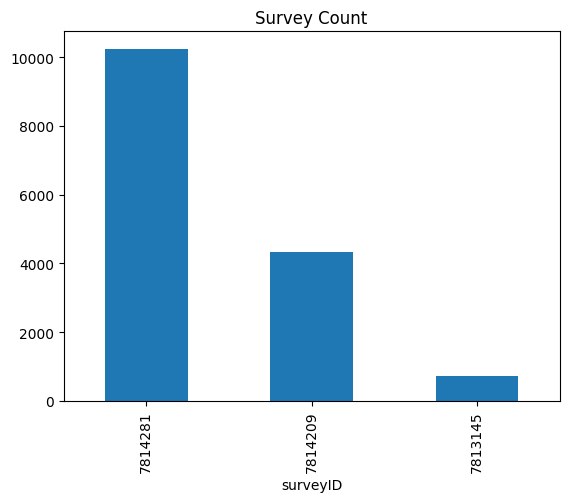

In [122]:
data['surveyID'].value_counts().plot(kind="bar",title="Survey Count")

In [123]:
data['responseID'].nunique()

680

In [124]:
maxi=data.groupby('surveyName')['location.country'].value_counts()
maxi

surveyName                location.country
18 Months Post VP Survey  Malaysia            9803
                          Singapore            248
                          Indonesia             39
                          Thailand              37
                          Hong Kong             36
                          Japan                 36
                          Luxembourg            36
Defects Survey            Malaysia            2923
                          Singapore            150
                          Vietnam               16
                          Hong Kong              5
Refund Survey             Malaysia             691
                          Singapore              9
                          South Korea            8
Name: count, dtype: int64

In [125]:
maxi.idxmax(),maxi.max(),maxi.idxmin(),maxi.min()

(('18 Months Post VP Survey', 'Malaysia'),
 np.int64(9803),
 ('Defects Survey', 'Hong Kong'),
 np.int64(5))

<Axes: title={'center': 'location survey count'}, xlabel='surveyName,location.country'>

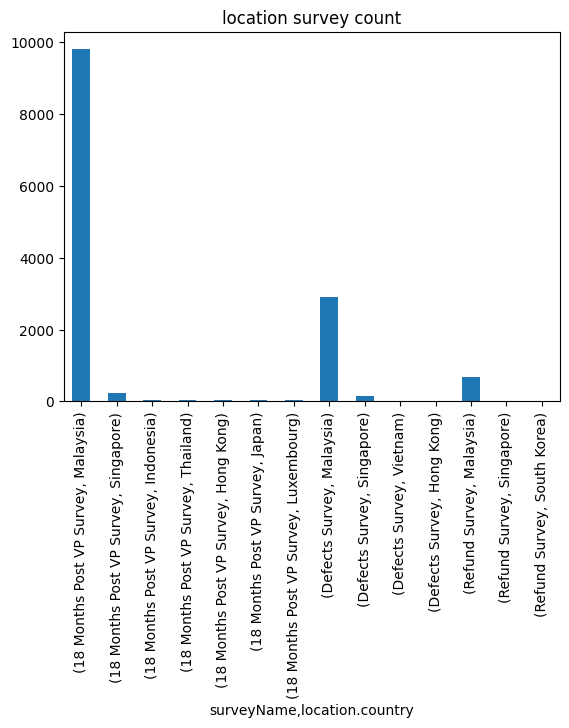

In [126]:
data.groupby('surveyName')['location.country'].value_counts().plot(kind='bar',title="location survey count")

<Axes: title={'center': 'No of reviewers from each location'}, xlabel='location.country'>

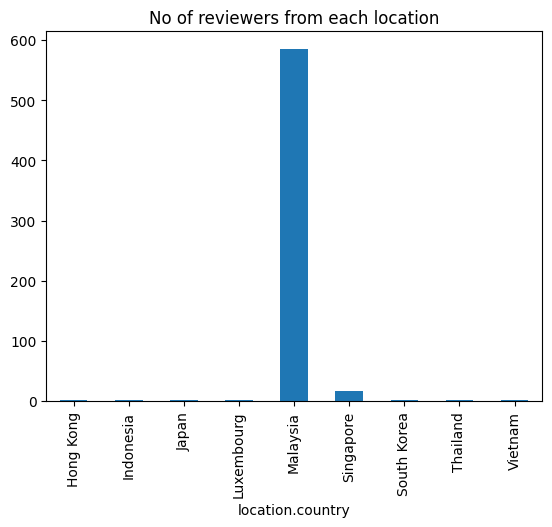

In [127]:
data.groupby('location.country')['responseID'].nunique().plot(kind='bar',title='No of reviewers from each location')

In [129]:
result.idxmax(),result.max()

('Malaysia', np.int64(585))

In [130]:
data.groupby('location.country')['responseID'].nunique()

location.country
Hong Kong        2
Indonesia        1
Japan            1
Luxembourg       1
Malaysia       585
Singapore       17
South Korea      1
Thailand         2
Vietnam          1
Name: responseID, dtype: int64

## 4. Null Analysis — Answer Columns

The dataset has two answer columns:
- `answerText` — MCQ selected answers (e.g. "Good", "Agree")
- `value.text` — Free-text typed responses

Both can be null independently. Understanding the null distribution guides how we merge them.

In [131]:
null_count = data['answerText'].isna().sum()
not_null_count = data['answerText'].notna().sum()

In [132]:
count_df = pd.Series({
    'Null': null_count,
    'Non-Null': not_null_count
})
count_df

Null         3550
Non-Null    11733
dtype: int64

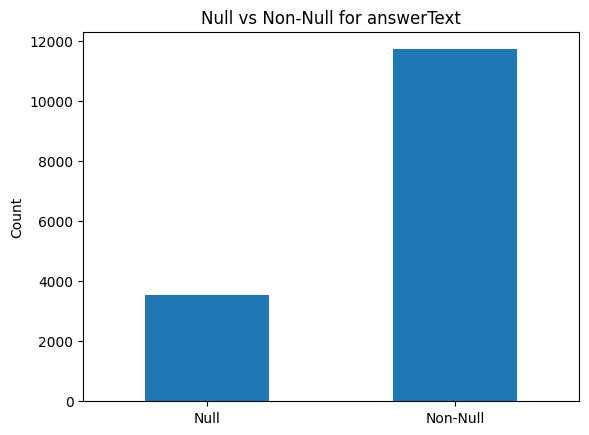

In [133]:
count_df.plot(kind='bar')
plt.title(f"Null vs Non-Null for answerText")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [134]:
null_count1 = data['value.text'].isna().sum()
not_null_count1 = data['value.text'].notna().sum()

In [135]:
count_df1 = pd.Series({
    'Null': null_count1,
    'Non-Null': not_null_count1
})
count_df1

Null        13460
Non-Null     1823
dtype: int64

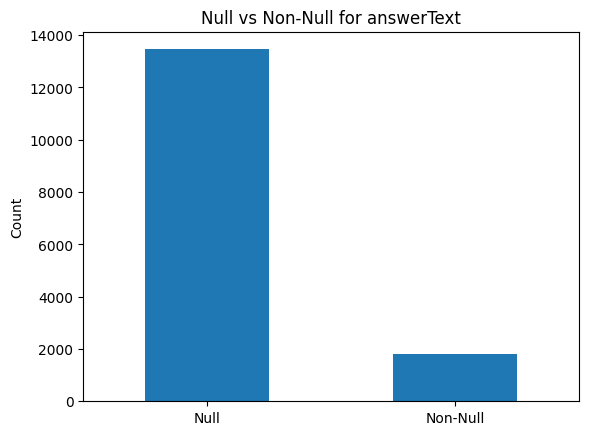

In [136]:
count_df1.plot(kind='bar')
plt.title(f"Null vs Non-Null for answerText")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

## 5. Question Analysis & Unicode Normalization

Analysing the unique questions in the survey.  
Malaysian survey data often contains unicode inconsistencies — fancy quotes, special characters —  
which cause the same question to appear as multiple distinct strings.  
Normalizing fixes this before grouping.

In [137]:
data.columns

Index(['Unnamed: 0', 'surveyID', 'surveyName', 'responseID', 'timestamp',
       'location.country', 'operatingSystem', 'browser', 'language',
       'timeTaken', 'responseStatus', 'emailAddress', 'questionCode',
       'questionText', 'answerText', 'value.text', 'Batch_Date'],
      dtype='object')

In [138]:
data['questionCode'].nunique()

45

In [139]:
data['questionText'].nunique()

62

In [140]:
import re
import unicodedata

def clean_text(text):
    # Normalize unicode → converts fancy quotes to standard
    text = unicodedata.normalize('NFKD', text)
    
    # Remove special characters except ?
    text = re.sub(r'[^a-zA-Z0-9\s?]', '', text)
    
    # Normalize spaces and lowercase
    text = re.sub(r'\s+', ' ', text).strip().lower()
    
    return text

In [141]:
data['questionText'].apply(clean_text)

0        how satisfied are you with the customer suppor...
1        wed like to ask you a few questions regarding ...
2                     your defect rectification experience
3        how likely would you recommend mah sings produ...
4            how easy is it to use the novade application?
                               ...                        
15278    would you like us to contact you for a followu...
15279    what can mah sing do to improve your satisfact...
15280    wed like to ask you a few questions regarding ...
15281                 your defect rectification experience
15282    how likely would you recommend mah sings produ...
Name: questionText, Length: 15283, dtype: object

In [142]:
data['questionText'].nunique()

62

In [143]:
quest=data.groupby(['questionCode','questionText']).agg(count=('questionText','count'))

In [144]:
quest

count
questionCode questionText                                             
Q1           How likely would you recommend Mah Sings produc...    345
             How likely would you recommend Mah Sing’s produ...    335
Q10          I find the offered services are highly useful a...     52
             What can Mah Sing do to improve your satisfacti...    200
Q11          I did not use any of the property support servi...    211
...                                                                ...
Q9           Have you used the property support services on ...    263
Q9_1         The Customer Service Representative was consist...    200
Q9_2         The Customer Service Representative understood ...    200
Q9_3         The Customer Service Representative was polite ...    200
Q9_4         The Customer Service Representative made me fee...    200

[63 rows x 1 columns]

In [145]:
quest.iloc[0]

count    345
Name: (Q1, How likely would you recommend Mah Sings product to a friend or colleague?), dtype: int64

In [146]:
df=data.groupby(['questionCode','questionText','answerText']).agg(a_count=('answerText','count'))

In [148]:
df.iloc[0:22,:]

a_count  \
questionCode questionText                                       answerText            
Q1           How likely would you recommend Mah Sings produc... 0                19   
                                                                1                 7   
                                                                10               80   
                                                                2                 9   
                                                                3                17   
                                                                4                 7   
                                                                5                36   
                                                                6                24   
                                                                7                48   
                                                                8                49   
                                                                9                49   
             How likely would you recommend Mah Sing’s produ... 0                17   
                                                                1                 7   
                                                                10               64   
                                                                2                 6   
                                                                3                 6   
                                                                4                 7   
                                                                5                31   
                                                                6                36   
                                                                7                52   
                                                                8                76   
                                                                9                33   

                                                                            percentage  
questionCode questionText                                       answerText              
Q1           How likely would you recommend Mah Sings produc... 0             2.794118  
                                                                1             1.029412  
                                                                10           11.764706  
                                                                2             1.323529  
                                                                3             2.500000  
                                                                4             1.029412  
                                                                5             5.294118  
                                                                6             3.529412  
                                                                7             7.058824  
                                                                8             7.205882  
                                                                9             7.205882  
             How likely would you recommend Mah Sing’s produ... 0             2.500000  
                                                                1             1.029412  
                                                                10            9.411765  
                                                                2             0.882353  
                                                                3             0.882353  
                                                                4             1.029412  
                                                                5             4.558824  
                                                                6             5.294118  
                                                                7             7.647059  
                             

## 6. Selecting Columns & Creating `model_input`

Narrowing to only the columns needed for sentiment analysis.

**Key design decision — merging two answer columns:**  
`answerText` (MCQ) takes priority. If it's null, `value.text` is used.  
If both are null, the row is dropped — it carries no sentiment signal.

This creates a single clean `model_input` column that feeds into the classifier.

In [152]:
sentiment_data=data[['responseID','questionCode','questionText','answerText','value.text']]

In [153]:
sentiment_data

,responseID,questionCode,questionText,answerText,value.text
0,142316144,Q20,How satisfied are you with the customer suppor...,Satisfied,NaN
1,142316144,Q4,Wed like to ask you a few questions regarding ...,NaN,NaN
2,142316144,Q3,Your defect rectification experience,NaN,NaN
3,142316144,Q1,How likely would you recommend Mah Sings produ...,8,NaN
4,142316144,Q18,How easy is it to use the Novade application?,Easy,NaN
...,...,...,...,...,...
15278,143924758,Q17,Would you like us to contact you for a follow-...,"Sure, feel free to contact me",NaN
15279,143924758,Q8,What can Mah Sing do to improve your satisfact...,NaN,"Have a better QC, the leaking was worse after ..."
15280,143928115,Q4,Wed like to ask you a few questions regarding ...,NaN,NaN
15281,143928115,Q3,Your defect rectification experience,NaN,NaN


In [154]:
sentiment_data.isnull().sum()

responseID          0
questionCode        0
questionText        0
answerText       3550
value.text      13460
dtype: int64

In [155]:
sentiment_data=sentiment_data[~(sentiment_data['answerText'].isna() & sentiment_data['value.text'].isna())]

In [156]:
sentiment_data

,responseID,questionCode,questionText,answerText,value.text
0,142316144,Q20,How satisfied are you with the customer suppor...,Satisfied,NaN
3,142316144,Q1,How likely would you recommend Mah Sings produ...,8,NaN
4,142316144,Q18,How easy is it to use the Novade application?,Easy,NaN
5,142317923,Q17,Would you like us to contact you for a follow-...,"Sure, feel free to contact me",NaN
6,142317923,Q16,Mobile Number For example +60191234567,NaN,60192379762
...,...,...,...,...,...
15276,143924758,Q15,Full Name (as per MyKad / Passport / Company R...,NaN,Nicole Yeow Yee Cheng
15277,143924758,Q16,Mobile Number For example +60191234567,NaN,162471588
15278,143924758,Q17,Would you like us to contact you for a follow-...,"Sure, feel free to contact me",NaN
15279,143924758,Q8,What can Mah Sing do to improve your satisfact...,NaN,"Have a better QC, the leaking was worse after ..."


In [157]:
sentiment_data.isnull().sum()

responseID          0
questionCode        0
questionText        0
answerText       1823
value.text      11733
dtype: int64

In [158]:
#creating the new column and cobining the answr and value column for that i created a function
def get_text(row):
    if pd.notna(row['answerText']):
        return row['answerText']
    return row['value.text']
sentiment_data['model_input'] = sentiment_data.apply(get_text, axis=1)

C:\Users\RameshSekar\AppData\Local\Temp\ipykernel_10524\2298647353.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sentiment_data['model_input'] = sentiment_data.apply(get_text, axis=1)


In [159]:
sentiment_data

,responseID,questionCode,questionText,answerText,value.text,model_input
0,142316144,Q20,How satisfied are you with the customer suppor...,Satisfied,NaN,Satisfied
3,142316144,Q1,How likely would you recommend Mah Sings produ...,8,NaN,8
4,142316144,Q18,How easy is it to use the Novade application?,Easy,NaN,Easy
5,142317923,Q17,Would you like us to contact you for a follow-...,"Sure, feel free to contact me",NaN,"Sure, feel free to contact me"
6,142317923,Q16,Mobile Number For example +60191234567,NaN,60192379762,60192379762
...,...,...,...,...,...,...
15276,143924758,Q15,Full Name (as per MyKad / Passport / Company R...,NaN,Nicole Yeow Yee Cheng,Nicole Yeow Yee Cheng
15277,143924758,Q16,Mobile Number For example +60191234567,NaN,162471588,162471588
15278,143924758,Q17,Would you like us to contact you for a follow-...,"Sure, feel free to contact me",NaN,"Sure, feel free to contact me"
15279,143924758,Q8,What can Mah Sing do to improve your satisfact...,NaN,"Have a better QC, the leaking was worse after ...","Have a better QC, the leaking was worse after ..."


In [160]:
sentiment_data['model_input'].value_counts().head(20)

model_input
Satisfied                                                                          2704
Neither satisfied nor dissatisfied                                                 1183
Agree                                                                              1174
Extremely satisfied                                                                1007
Neither agree nor disagree                                                          624
Strongly agree                                                                      449
Dissatisfied                                                                        358
Yes                                                                                 295
No, please dont contact me                                                          293
No                                                                                  245
Extremely dissatisfied                                                              204
Sure, feel free to c

## 7. Removing Non-Sentiment Questions

Not all questions carry sentiment — some ask for names, ID numbers, or numeric ratings.  
These were identified manually by reviewing unique question texts.  
Including them would add noise and confuse the classifier.

In [161]:
# before this i manually noticed that some answers are in the numeric ormat other than rating way
import re

df_digits = sentiment_data[sentiment_data['model_input'].astype(str).str.contains(r'\d{4,}', regex=True, na=False)][
    ['model_input', 'questionCode', 'questionText']
]

df_digits.head(20)

,model_input,questionCode,questionText
6,60192379762,Q16,Mobile Number For example +60191234567
88,177467715,Q16,Mobile Number For example +60191234567
130,122568380,Q16,Mobile Number For example +60191234567
151,189117070,Q16,Mobile Number For example +60191234567
170,60125590591,Q16,Mobile Number For example +60191234567
186,1121990316,Q16,Mobile Number For example +60191234567
200,199076077,Q16,Mobile Number For example +60191234567
221,175163908,Q16,Mobile Number For example +60191234567
243,132488454,Q16,Mobile Number For example +60191234567
274,127847604,Q16,Mobile Number For example +60191234567


In [162]:
sentiment_data['questionText'].unique(),sentiment_data['questionText'].nunique()

(array(['How satisfied are you with the customer support provided for the Novade application? ',
        'How likely would you recommend Mah Sings product to a friend or colleague?',
        'How easy is it to use the Novade application? ',
        'Would you like us to contact you for a follow-up discussion?',
        'Mobile Number For example +60191234567',
        'Full Name (as per MyKad / Passport / Company Registration) For example: Lim Siew Sin',
        'Property Purchased (A-Z List of Projects)',
        'The Customer Service Representative made me feel cared for',
        'The Customer Service Representative was polite and friendly',
        'The Customer Service Representative understood my defect rectification submission',
        'The Customer Service Representative was consistently prompt in his/her response',
        'The appointment date/time given to you',
        'Completion of defects rectification within committed timeframe',
        'How likely are you to purchase

In [168]:
uni_quest

,questionText
0,How satisfied are you with the customer suppor...
1,How likely would you recommend Mah Sings produ...
2,How easy is it to use the Novade application?
3,Would you like us to contact you for a follow-...
4,Mobile Number For example +60191234567
5,Full Name (as per MyKad / Passport / Company R...
6,Property Purchased (A-Z List of Projects)
7,The Customer Service Representative made me fe...
8,The Customer Service Representative was polite...
9,The Customer Service Representative understood...


In [170]:
no_sentiment_qs =['Full Name (as per MyKad / Passport / Company Registration) For example: Lim Siew Sin','Have you used the property support services on M Concierge before?','Have you downloaded and used MY Mah Sing app? ','Property Booked (A-Z List of Projects)','Property Purchased (A-Z List of Projects)','Mobile Number For example +60191234567']

In [172]:
sentiment_data = sentiment_data[~sentiment_data["questionText"].isin(no_sentiment_qs)]

In [173]:
sentiment_data.shape

(11542, 6)

## 8. Text Preprocessing

Deep cleaning of `model_input`:
- **Unicode normalization** — handles Malay/mixed-language special characters
- **Whitespace stripping** and standardization
- **Validity filter** — removes purely numeric entries, single characters, and empty strings

Only responses with at least one letter and meaningful content are kept.

In [163]:
import re
import unicodedata

def preprocess_text(text):
    if not isinstance(text, str):
        return ""

    # 1. Normalize unicode (handles fancy quotes, accents, etc.)
    text = unicodedata.normalize('NFKD', text)

    # 2. Remove special characters (keep letters, numbers, space, ?)
    text = re.sub(r'[^a-zA-Z0-9\s?]', '', text)

    # 3. Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # 4. Lowercase (important for NLP consistency)
    text = text.lower()

    return text

In [164]:
sentiment_data['model_input'] = sentiment_data['model_input'].apply(preprocess_text)

C:\Users\RameshSekar\AppData\Local\Temp\ipykernel_10524\3662768670.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sentiment_data['model_input'] = sentiment_data['model_input'].apply(preprocess_text)


In [165]:
sentiment_data['model_input'].str.contains(" ").sum()

np.int64(6817)

In [176]:
def clean_text(text):
    text = str(text)
    text = text.strip()
    return text

In [177]:
import re

def is_valid_text(text):
    text = str(text).strip()
    
    # Must contain at least one letter
    if not re.search(r'[^\W\d_]', text):
        return False
    
    # Minimum length
    if len(text) < 2:
        return False
        
    return True

In [178]:
sentiment_data['model_input'] = sentiment_data['model_input'].apply(clean_text)
sentiment_data = sentiment_data[sentiment_data['model_input'].apply(is_valid_text)]

C:\Users\RameshSekar\AppData\Local\Temp\ipykernel_10524\2377554760.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sentiment_data['model_input'] = sentiment_data['model_input'].apply(clean_text)


In [179]:
sentiment_data.shape

(10776, 6)

In [180]:
sentiment_data.columns

Index(['responseID', 'questionCode', 'questionText', 'answerText',
       'value.text', 'model_input'],
      dtype='object')

In [182]:
sentiment_data['model_input'].unique()

array(['satisfied', 'easy', 'sure feel free to contact me', 'agree',
       'likely', 'no please dont contact me', 'strongly agree',
       'neither satisfied nor dissatisfied', 'speed',
       'extremely satisfied', 'neither agree nor disagree',
       'dissatisfied', 'neither easy nor difficult', 'very unlikely',
       'unlikely nor likely',
       'contractor shall ensure the defects are fully solve', 'very easy',
       'customer service office should be open early',
       'allowed customer to submit report without using apps defect major defect should be check by your team before give the key',
       'improve the quality first before think about the repairing',
       'very likely', 'visibility on major defect',
       'make sure workmanship meet top tier standards the workmanship is horrible even after submitting some issues issues are marked completedresolved but pictures show the workmanship is still very poor and barely fixed anything painting work especially',
       'extr

In [183]:
sentiment_data

,responseID,questionCode,questionText,model_input
0,142316144,Q20,How satisfied are you with the customer suppor...,satisfied
4,142316144,Q18,How easy is it to use the Novade application?,easy
5,142317923,Q17,Would you like us to contact you for a follow-...,sure feel free to contact me
10,142317923,Q9_4,The Customer Service Representative made me fe...,agree
11,142317923,Q9_3,The Customer Service Representative was polite...,agree
...,...,...,...,...
15271,143924758,Q9_2,The Customer Service Representative understood...,agree
15272,143924758,Q9_4,The Customer Service Representative made me fe...,agree
15274,143924758,Q13,How likely are you to purchase again from Mah ...,unlikely
15278,143924758,Q17,Would you like us to contact you for a follow-...,sure feel free to contact me


## 9. Text Type Routing — Closed vs Open

**This is the core of the hybrid approach.**

A rule-based function classifies each response into:
- **Closed** — Short responses (single word or short phrase like "Good", "Satisfied", "Agree")  
  → Rule-based keyword classifier (fast, no API cost)
- **Open** — Longer free-form sentences requiring contextual understanding  
  → Sent to LLM (Groq API)

This routing saves significant API cost — only complex responses go to the LLM.

In [185]:
sentiment_data['responseID'].value_counts().max(),sentiment_data['responseID'].value_counts().idxmax()

(np.int64(36), np.int64(142522890))

In [186]:
def classify_text_type(text):
    text = str(text).strip()
    
    # Short responses → closed
    if len(text.split()) <3:
        return "closed"
    
    return "open"

In [187]:
sentiment_data['text_type'] = sentiment_data['model_input'].apply(classify_text_type)

In [188]:
close_data=sentiment_data[sentiment_data['text_type'] == 'closed']

In [190]:
open_data=sentiment_data[sentiment_data['text_type'] == 'open'] 

In [193]:
len(cc)

117

In [194]:
len(sentiment_data)

10776

## 10. Closed-Text Classification — Rule-Based

For closed-text responses, a keyword matcher assigns sentiment directly.  

**Why not use LLM here?**  
When the answer is literally the word "Good" or "Satisfied", an LLM adds no value.  
The rule-based approach is instant, free, and 100% accurate for these cases.

Responses that don't match any keyword are tagged `'open'` for LLM processing.

In [196]:
positive_words = [
    "good", "satisfied", "agree", "easy", "positive", "likely"
]

negative_words = [
    "bad", "dissatisfied", "disagree", "difficult", "negative", "slow"
]

neutral_words = [
    "na", "none", "no comment", "idk", "nothing"
]

In [197]:
def classify_sentiment(text):
    text = str(text)
    
    if text in positive_words:
        return "Positive"
    elif text in negative_words:
        return "Negative"
    elif text in neutral_words:
        return "Neutral"
    else:
        return "open"

In [198]:
sentiment_data['sentiment'] = sentiment_data['model_input'].apply(classify_sentiment)

In [199]:
sentiment_data.columns

Index(['responseID', 'questionCode', 'questionText', 'model_input',
       'text_type', 'sentiment'],
      dtype='object')

In [200]:
sentiment_data = sentiment_data.groupby([
    'responseID', 'questionCode', 'questionText', 
    'model_input', 'text_type', 'sentiment'
]).agg(count=('model_input', 'count')).reset_index()

In [201]:
# so no duplicates here 
sentiment_data[sentiment_data['count']>1]

,responseID,questionCode,questionText,model_input,text_type,sentiment,count


In [202]:
len(sentiment_data)

10776

In [203]:
sentiment_data.drop(columns=['count'], inplace=True)

In [204]:
sentiment_data['responseID'].nunique()

642

## 11. Open-Text Classification — LLM via Groq API ⭐

**This is the most critical part of the pipeline.**

Open-text responses are free-form sentences in English, Malay, or mixed language.  
No keyword rule can reliably classify these — they require contextual understanding.

**Solution:** Groq API with **Moonshot AI (Kimi-K2)** — a fast, multilingual LLM.

**Batching strategy:**
- ~6,000 open-text responses split into 3 batches of ~2,000 each
- Each batch processed with rate-limit handling and retry logic
- Results saved to CSV after each batch — so no data is lost if interrupted
- Final results combined into `sentiment_final.csv`

> **To reproduce:** Set `GROQ_API_KEY` in a `.env` file. Never commit keys to GitHub.

In [205]:
open_text_data=sentiment_data[sentiment_data['sentiment'] == 'open'].reset_index(drop=True)

In [206]:
open_text_data['questionText'].nunique()

51

In [207]:
# Load API key securely from environment variable
# Create a .env file locally with: GROQ_API_KEY=your_key_here
# Add .env to your .gitignore — never commit API keys to GitHub

import os
from dotenv import load_dotenv
import json
from groq import Groq
import time

load_dotenv()
api_key = os.getenv("GROQ_API_KEY")
client = Groq(api_key=api_key)

In [211]:
def classify_batch_groq(texts, model):
    formatted = [
        f"{i+1}. Q: {row['questionText']} | A: {row['model_input']}"
        for i, (_, row) in enumerate(texts.iterrows())
    ]

    messages = [
        {
            "role": "system",
            "content": (
                "You are a sentiment classifier for customer survey responses. "
"You will be given a question and its answer. "
"Classify the sentiment of the ANSWER in context of the QUESTION "
"into EXACTLY one of these words: Positive, Negative, Neutral. "
"Rules: "
"1. Use ONLY these exact words: Positive, Negative, Neutral. "
"2. Do NOT use any other words like Noise, Strongly, Very, Yes, No, Unlikely or any variations. "
"3. If the answer is irrelevant or nonsensical, classify as Neutral. "
"4. Return ONLY a JSON array, one label per input, nothing else. "
"Example input: 2 items. Example output: [\"Positive\", \"Negative\"]"            )
        },
        {
            "role": "user",
            "content": "\n".join(formatted)
        }
    ]

    # Set max tokens based on model type
    reasoning_models = ["openai/gpt-oss-120b", "openai/gpt-oss-20b"]
    max_tokens = 8192 if model in reasoning_models else 512

    for attempt in range(3):
        try:
            response = client.chat.completions.create(
                model=model,
                messages=messages,
                temperature=0,
                max_completion_tokens=max_tokens
            )

            raw = response.choices[0].message.content
            finish_reason = response.choices[0].finish_reason

            if finish_reason == "length":
                print(f"⚠️ Token limit hit on attempt {attempt+1}, retrying...")
                time.sleep(3)
                continue

            if not raw or not raw.strip():
                print(f"⚠️ Empty response on attempt {attempt+1}, retrying...")
                time.sleep(3)
                continue

            # Replace with this
            match = re.search(r'\[.*?\]', raw, re.DOTALL)
            if match:
                raw = match.group(0)
            else:
                print(f"⚠️ No JSON array found, retrying...")
                time.sleep(3)
                continue

            preds = json.loads(raw)

            if len(preds) != len(texts):
                print(f"⚠️ Length mismatch: expected {len(texts)}, got {len(preds)}")
                preds = (preds + ["Neutral"] * len(texts))[:len(texts)]

            return preds

        except json.JSONDecodeError as e:
            print(f"❌ JSON error on attempt {attempt+1}: {e} | Raw: {repr(raw[:100])}")
            time.sleep(3)

        except Exception as e:
            print(f"❌ Error on attempt {attempt+1}: {e}")
            time.sleep(3)

    print("❌ All retries failed, defaulting to Neutral")
    return ["Neutral"] * len(texts)


def run_classification(data, model, label):
    batch_size = 50
    predictions = []

    for i in range(0, len(data), batch_size):
        batch = data[["questionText", "model_input"]].iloc[i : i + batch_size]
        preds = classify_batch_groq(batch, model=model)  # model passed here
        predictions.extend(preds)
        print(f"[{label}] ✅ {min(i + batch_size, len(data))}/{len(data)} rows done")
        time.sleep(2)

    return predictions


In [ ]:
import time

# Split into 3 parts
split1 = open_text_data.iloc[:2000]
split2 = open_text_data.iloc[2000:4000]
split3 = open_text_data.iloc[4000:]
def run_classification(data, model, label):
    batch_size = 50
    predictions = []
    
    for i in range(0, len(data), batch_size):
        batch = data[["questionText", "model_input"]].iloc[i : i + batch_size]
        preds = classify_batch_groq(batch, model=model)
        predictions.extend(preds)
        print(f"[{label}] ✅ {min(i + batch_size, len(data))}/{len(data)} rows done")
        time.sleep(2)
    
    return predictions

# Split 1 - llama-4-scout
print("\n🚀 Starting Split 1...")
preds1 = run_classification(split1, "moonshotai/kimi-k2-instruct", "Split1")
split1 = split1.copy()
split1.loc[:, "sentiment"] = preds1
split1.to_csv("split1_done.csv", index=False)
print("✅ Split 1 done & saved!")


Split 1: 2000 rows → llama-4-scout
Split 2: 2000 rows → llama-3.1-8b-instant
Split 3: 1922 rows → openai/gpt-oss-20b

🚀 Starting Split 1...
[Split1] ✅ 50/2000 rows done
[Split1] ✅ 100/2000 rows done
[Split1] ✅ 150/2000 rows done
[Split1] ✅ 200/2000 rows done
[Split1] ✅ 250/2000 rows done
[Split1] ✅ 300/2000 rows done
[Split1] ✅ 350/2000 rows done
[Split1] ✅ 400/2000 rows done
[Split1] ✅ 450/2000 rows done
[Split1] ✅ 500/2000 rows done
[Split1] ✅ 550/2000 rows done
[Split1] ✅ 600/2000 rows done
[Split1] ✅ 650/2000 rows done
[Split1] ✅ 700/2000 rows done
[Split1] ✅ 750/2000 rows done
[Split1] ✅ 800/2000 rows done
[Split1] ✅ 850/2000 rows done
[Split1] ✅ 900/2000 rows done
[Split1] ✅ 950/2000 rows done
[Split1] ✅ 1000/2000 rows done
⚠️ Length mismatch: expected 50, got 49
[Split1] ✅ 1050/2000 rows done
[Split1] ✅ 1100/2000 rows done
[Split1] ✅ 1150/2000 rows done
[Split1] ✅ 1200/2000 rows done
[Split1] ✅ 1250/2000 rows done
[Split1] ✅ 1300/2000 rows done
[Split1] ✅ 1350/2000 rows done
[Sp

In [219]:
# Split 2 - llama-3.1-8b-instant
print("\n🚀 Starting Split 2...")
preds2 = run_classification(split2, "moonshotai/kimi-k2-instruct", "Split2")
split2 = split2.copy()
split2.loc[:, "sentiment"] = preds2
split2.to_csv("split2_done.csv", index=False)
print("✅ Split 2 done & saved!")



🚀 Starting Split 2...
[Split2] ✅ 50/2000 rows done
[Split2] ✅ 100/2000 rows done
[Split2] ✅ 150/2000 rows done
[Split2] ✅ 200/2000 rows done
[Split2] ✅ 250/2000 rows done
[Split2] ✅ 300/2000 rows done
[Split2] ✅ 350/2000 rows done
[Split2] ✅ 400/2000 rows done
[Split2] ✅ 450/2000 rows done
[Split2] ✅ 500/2000 rows done
[Split2] ✅ 550/2000 rows done
[Split2] ✅ 600/2000 rows done
[Split2] ✅ 650/2000 rows done
⚠️ Length mismatch: expected 50, got 49
[Split2] ✅ 700/2000 rows done
[Split2] ✅ 750/2000 rows done
[Split2] ✅ 800/2000 rows done
[Split2] ✅ 850/2000 rows done
[Split2] ✅ 900/2000 rows done
[Split2] ✅ 950/2000 rows done
[Split2] ✅ 1000/2000 rows done
⚠️ Length mismatch: expected 50, got 49
[Split2] ✅ 1050/2000 rows done
[Split2] ✅ 1100/2000 rows done
[Split2] ✅ 1150/2000 rows done
[Split2] ✅ 1200/2000 rows done
[Split2] ✅ 1250/2000 rows done
⚠️ Length mismatch: expected 50, got 51
[Split2] ✅ 1300/2000 rows done
[Split2] ✅ 1350/2000 rows done
[Split2] ✅ 1400/2000 rows done
[Split2] 

In [218]:
# Split 3 - gpt-oss-20b
print("\n🚀 Starting Split 3...")
preds3 = run_classification(split3, "moonshotai/kimi-k2-instruct", "Split3")
split3 = split3.copy()
split3.loc[:, "sentiment"] = preds3
split3.to_csv("split3_done.csv", index=False)
print("✅ Split 3 done & saved!")


🚀 Starting Split 3...
[Split3] ✅ 50/1922 rows done
[Split3] ✅ 100/1922 rows done
[Split3] ✅ 150/1922 rows done
[Split3] ✅ 200/1922 rows done
[Split3] ✅ 250/1922 rows done
[Split3] ✅ 300/1922 rows done
[Split3] ✅ 350/1922 rows done
[Split3] ✅ 400/1922 rows done
[Split3] ✅ 450/1922 rows done
[Split3] ✅ 500/1922 rows done
[Split3] ✅ 550/1922 rows done
[Split3] ✅ 600/1922 rows done
[Split3] ✅ 650/1922 rows done
[Split3] ✅ 700/1922 rows done
[Split3] ✅ 750/1922 rows done
[Split3] ✅ 800/1922 rows done
[Split3] ✅ 850/1922 rows done
[Split3] ✅ 900/1922 rows done
[Split3] ✅ 950/1922 rows done
[Split3] ✅ 1000/1922 rows done
[Split3] ✅ 1050/1922 rows done
[Split3] ✅ 1100/1922 rows done
[Split3] ✅ 1150/1922 rows done
[Split3] ✅ 1200/1922 rows done
[Split3] ✅ 1250/1922 rows done
[Split3] ✅ 1300/1922 rows done
[Split3] ✅ 1350/1922 rows done
[Split3] ✅ 1400/1922 rows done
[Split3] ✅ 1450/1922 rows done
[Split3] ✅ 1500/1922 rows done
[Split3] ✅ 1550/1922 rows done
[Split3] ✅ 1600/1922 rows done
[Spli

## 12. Combining Results & Final Output

After all three batches complete, results are merged into a single dataframe.  
The final `sentiment_final.csv` contains per-user, per-question sentiment labels  
ready for business reporting and user-level analysis.

In [223]:
split1=pd.read_csv("split1_done.csv")
split2=pd.read_csv("split2_done.csv")
split3=pd.read_csv("split3_done.csv")

In [224]:
# Combine all back
open_text_data = pd.concat([split1, split2, split3], ignore_index=True)
open_text_data.to_csv("sentiment_final.csv", index=False)
print(f"\n🎉 All {len(open_text_data)} rows classified and saved!")


🎉 All 5922 rows classified and saved!


In [ ]:
open_text_data

,responseID,questionCode,questionText,model_input,text_type,sentiment
3,142317923,Q17,Would you like us to contact you for a follow-...,sure feel free to contact me,open,open
15,142317996,Q17,Would you like us to contact you for a follow-...,no please dont contact me,open,open
20,142317996,Q7_3,The quality of workmanship for defects rectified,neither satisfied nor dissatisfied,open,open
24,142317996,Q9_3,The Customer Service Representative was polite...,strongly agree,closed,open
25,142317996,Q9_4,The Customer Service Representative made me fe...,strongly agree,closed,open
...,...,...,...,...,...,...
10764,143924758,Q17,Would you like us to contact you for a follow-...,sure feel free to contact me,open,open
10765,143924758,Q18,How easy is it to use the Novade application?,neither easy nor difficult,open,open
10767,143924758,Q7_1,Ease of scheduling a joint inspection appointment,neither satisfied nor dissatisfied,open,open
10771,143924758,Q8,What can Mah Sing do to improve your satisfact...,have a better qc the leaking was worse after r...,open,open


In [ ]:
open_text_data['sentiment'].value_counts()

sentiment
open    5922
Name: count, dtype: int64

---

## ✅ Pipeline Summary

| Stage | Method | Output |
|---|---|---|
| Data Loading | `pd.read_excel` / `pd.concat` | Combined survey dataframe |
| EDA | Groupby, value counts, bar plots | Geographic & survey insights |
| Text Merging | Priority merge (`answerText` → `value.text`) | `model_input` column |
| Question Filtering | Manual review + exclusion list | Clean sentiment-only questions |
| Text Preprocessing | Unicode norm, validity filter | Clean `model_input` |
| Text Type Routing | Rule-based length/word classifier | `closed` / `open` labels |
| Closed-Text Sentiment | Keyword rule classifier | Positive / Negative / Neutral |
| Open-Text Sentiment | **Groq API — Moonshot AI (Kimi-K2)** | Positive / Negative / Neutral |
| Final Output | `pd.concat` + CSV export | `sentiment_final.csv` |

### Key Engineering Decisions
- **Hybrid approach** drastically reduces API cost — only complex responses hit the LLM
- **Batched processing** with CSV checkpointing prevents data loss on interruptions
- **Unicode normalization** essential for Malaysian multilingual data quality
- **Groq API** chosen for its speed advantage on large-volume batch inference

### Output File
`sentiment_final.csv` — columns: `responseID`, `questionCode`, `questionText`, `model_input`, `text_type`, `sentiment`
